# Загрузка изображения и представление его матрицей

In [ ]:
import cv2
import numpy as np

image_path = r"picture1.png"  #никакой кириллицы тут в пути!!!
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError('Изображение не грузанулось')

img = cv2.resize(img, (256, 256))

imgf = img.astype(np.float64)
print(imgf)

[[ 58.  61.  61. ... 124. 124. 124.]
 [ 58.  60.  61. ... 124. 125. 124.]
 [ 60.  60.  61. ... 125. 125. 124.]
 ...
 [ 97.  96.  94. ...  68.  71.  87.]
 [170. 170. 169. ...  68.  72.  85.]
 [216. 217. 216. ...  67.  72.  75.]]


# Применение преобразований

In [3]:
#>>>-------------------------Адамар-------------------------------------->
def hadamard_matrix(n):      #n - это СТЕПЕНЬ 2!
    if n == 1:
        return np.array([[1]])
    Hn = hadamard_matrix(n // 2)
    top = np.hstack((Hn, Hn))   #как конкатенация, только двух матриц одинаковой размерности
    bottom = np.hstack((Hn, -Hn))  #типа к матрице сбоку приписываем ещё одну матрицу
    return np.vstack((top, bottom))  #аналогичное только матрице приписываем матрицу снизу

HadaM = hadamard_matrix(256)
res_hada = HadaM @ img @ HadaM.T


#>>>-------------------------dct-------------------------------------->
def dct_matrix(n):
    D = np.zeros((n, n))
    for p in range(n):
        for q in range(n):
            if p == 0:
                alpha = np.sqrt(1/n)
            else:
                alpha = np.sqrt(2/n)
            D[p, q] = alpha * np.cos(np.pi * (q + 0.5) * p / n)
    return D

dctM = dct_matrix(256)
res_dct = dctM @ imgf @ dctM.T


#>>>-------------------------pca-------------------------------------->

X = img - np.mean(img, axis=0)
cov = np.cov(X, rowvar=False)
eig_vals, eig_vecs = np.linalg.eigh(cov)
idx = np.argsort(eig_vals)[::-1]
eig_vecs = eig_vecs[:, idx]
k = 64
W = eig_vecs[:, :k]

res_pca = X @ W


# Подсчёт средней дисперсии для каждого М

In [4]:
from scipy.fftpack import idct

M_val = [16, 32, 64, 80, 100]
los_had = list()
los_dct = list()
los_pca = list()

for M in M_val:

    #>>>-------------------------Адамар-------------------------------------->
    cut = np.zeros_like(res_hada)
    cut[:M, :M] = res_hada[:M, :M]
    H = hadamard_matrix(256)   #256 - высота изображения
    img_back_had = (H.T @ cut @ H) / (img.shape[0] ** 2)
    img_back_had = np.clip(img_back_had, 0, 255).astype(np.uint8)
    
    #>>>-------------------------dct-------------------------------------->
    cut = np.zeros_like(res_dct)
    cut[:M, :M] = res_dct[:M, :M]
    img_back_dct = idct(idct(cut.T, norm='ortho').T, norm='ortho')
    img_back_dct = np.clip(img_back_dct, 0, 255).astype(np.uint8)

    #>>>-------------------------pca-------------------------------------->
    W_cut = W[:, :M]
    res_pca_cut = X @ W_cut
    img_back_pca = res_pca_cut @ W_cut.T + np.mean(img, axis=0)
    img_back_pca = np.clip(img_back_pca, 0, 255).astype(np.uint8)

    #>>>-------------------------Дисперсия-------------------------------------->
    disp_had = 0
    disp_dct = 0
    disp_pca = 0
    img_back_had = img_back_had.astype(np.float64)
    img_back_dct = img_back_dct.astype(np.float64)
    img_back_pca = img_back_pca.astype(np.float64)

    for i in range(0, 256):
        for j in range(0, 256):
            disp_had = disp_had + ((imgf[i][j] - img_back_had[i][j]) / 256) ** 2
            disp_dct = disp_dct + ((imgf[i][j] - img_back_dct[i][j]) / 256) ** 2
            disp_pca = disp_pca + ((imgf[i][j] - img_back_pca[i][j]) / 256) ** 2

    los_had.append(disp_had)
    los_dct.append(disp_dct)
    los_pca.append(disp_pca)

#print(los_had)
#print(los_dct)
#print(los_pca)

# Построение графиков

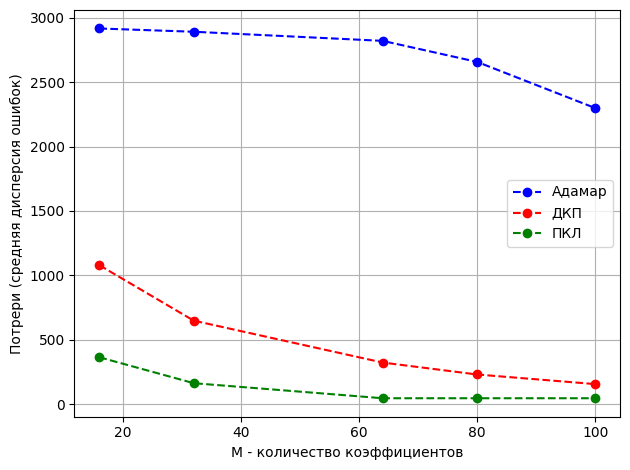

In [5]:
import matplotlib.pyplot as plt

plt.plot(M_val, los_had, 'b--o', label='Адамар')
plt.plot(M_val, los_dct, 'r--o', label='ДКП')
plt.plot(M_val, los_pca, 'g--o', label='ПКЛ')
plt.xlabel("М - количество коэффициентов")
plt.ylabel("Потрери (средняя дисперсия ошибок)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()